In [ ]:
import torch   
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F 


In [2]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

with_cuda = torch.cuda.is_available()
if with_cuda:
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from preprocessing import normalization, denormalization
import os
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import random_split, DataLoader, Dataset

In [4]:
print(device)

cuda


In [5]:
def train_loader(spec_path):
    batch_size = 5
    train_data = []
    for fichier in os.listdir(spec_path):
        if fichier.endswith(".npy"):  # Vérifier si le fichier est un fichier npy
            fichier_spec = os.path.join(spec_path, fichier)
            
            # Charger le spectrogramme
            log_spectrogram = np.load(fichier_spec)
            
            # Convertir en tenseur PyTorch et ajouter une dimension pour le canal
            log_spectrogram_tensor = torch.from_numpy(log_spectrogram).float().to(device)
            
            # Normaliser les valeurs entre 0 et 1
            mini , maxi = log_spectrogram_tensor.min(), log_spectrogram_tensor.max()
            normalize_tensor = normalization(log_spectrogram_tensor, mini , maxi)
            # Ajouter le tenseur à la liste des données d'entraînement
            
            train_data.append((normalize_tensor, mini, maxi)) 

    specs, mins, maxs = zip(*train_data)
    train_data = torch.utils.data.TensorDataset(torch.stack(specs),
                                                torch.stack(mins).unsqueeze(1),
                                                torch.stack(maxs).unsqueeze(1))

    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size)
    return train_loader

In [6]:
class RNN_autoencoder(nn.Module):
    def __init__(self, input_dim=1025, hidden_dim=500): #800 bien pour spec
        super(RNN_autoencoder, self).__init__()
        self.encoder = nn.RNN(input_dim, hidden_dim,  num_layers=1 , batch_first=True)
        self.decoder = nn.RNN(hidden_dim, hidden_dim, num_layers=1 , batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, input_dim)        
        
    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(1, batch_size, 500).to(x.device)
        latent, h_enc = self.encoder(x, h0)
        output, _ = self.decoder(latent, h_enc)
        output2 = self.output_layer(output)  # final projection
        return output2


In [7]:
import torch
print(torch.__version__)           # Version de PyTorch
print(torch.version.cuda)          # Version CUDA liée à PyTorch (None = CPU-only)
print(torch.backends.cudnn.version())  # Version cuDNN

2.6.0+cu126
12.6
90501


In [8]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [9]:
def split_sequence2(input_tensor, chunk_len=200): 
    # input_tensor: (batch, 1025, 2000)
    input_tensor = input_tensor.permute(0, 2, 1)  # (batch, time, freq) = (B, 2000, 1025)
    batch, total_len, feat = input_tensor.shape
    num_chunks = total_len // chunk_len
    input_tensor = input_tensor[:, :num_chunks * chunk_len, :]  # truncate
    chunks = input_tensor.reshape(batch * num_chunks, chunk_len, feat)  # (B*num_chunks, chunk_len, feat)
    return chunks

def split_sequence(input_tensor, chunk_len=200):# faut que 2000 soit un multiple de chunk_len
    # input_tensor: (batch, 1025, 2000)
    input_tensor = input_tensor.permute(0, 2, 1)  # (batch, time, freq) = (B, 2000, 1025)
    batch, total_len, feat = input_tensor.shape
    num_chunks = total_len // chunk_len

    input_tensor = input_tensor.contiguous().view(batch*num_chunks, chunk_len, feat)  
    return input_tensor
#marche pas à changer reflechir 

In [ ]:
def testeur(data_loader, model, device , epoch , loss_test, loss_affichage):
    path = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\P1\\projet deep L3S2\\images_Rnn"
    
    original, mini, maxi = data_loader.dataset[8]
    original = original.unsqueeze(0).to(device)
    mini = mini.item()
    maxi = maxi.item()
    
    with torch.no_grad():
        # Reconstruction
        original_input = original.permute(0, 2, 1)  # (1, 2000, 1025)
        reconstructed = model(original_input).permute(0, 2, 1)  # (1, 1025, 2000)

    original = original.squeeze(0).cpu().detach().numpy()
    reconstructed = reconstructed.squeeze(0).cpu().detach().numpy()


    original = denormalization(original, mini, maxi)

    reconstructed2 = denormalization(reconstructed, mini, maxi)
    
    def save_audio_original(path, spec, epoch):
        # Enregistrer le fichier audio
        audio_path = os.path.join(path + "\\son", f"audio_original.wav")
        spec_amp = librosa.db_to_amplitude(spec)
        signal = librosa.griffinlim(spec_amp, hop_length=512)
        sf.write(audio_path, signal, 22050)
         
        
    def save_audio_reconstructed(path, spec, epoch):
        # Enregistrer le fichier audio
        audio_path = os.path.join(path + "\\son", f"audio_reconstruit{epoch}.wav")
        spec_amp = librosa.db_to_amplitude(spec)
        signal = librosa.griffinlim(spec_amp, hop_length=512)

        sf.write(audio_path, signal, 22050)
        
    def save_image_original(path, image, epoch):
        # Enregistrer l'image
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(image, y_axis='log', x_axis='time')
        plt.colorbar(format='%+2.0f dB')
        plt.title(f"{image} : {epoch}")
        img_path = os.path.join(path + "\\images" , "images_original.png")
        plt.savefig(img_path)
        plt.close()
        
    def save_image_reconstruit(path, image, epoch):
        # Enregistrer l'image
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(image, y_axis='log', x_axis='time')
        plt.colorbar(format='%+2.0f dB')
        plt.title(f"{image} : {epoch}")
        img_path = os.path.join(path + "\\images", f"images_reconstuites{epoch}.png")
        plt.savefig(img_path)
        plt.close()
        
        
    save_audio_original(path, original, epoch)
    save_audio_reconstructed(path, reconstructed2, epoch)
    save_image_original(path, original, epoch)
    save_image_reconstruit(path, reconstructed2, epoch)
    
    if epoch > 0 : 
        plt.figure(figsize=(10, 4))
        train = list(range(len(loss_affichage)))         # [0, 1, 2, ..., 49]
        test = list(range(0, epoch+1 , 10))   # [0, 10, 20, 30, 40]
   
        # 2. Les courbes
        plt.plot(train, loss_affichage, label='Train Loss', color='blue')
        plt.plot(test, loss_test, label='Test Loss', color='orange', marker='o')

        # 3. Habillage
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Train vs Test Loss')
        plt.legend()
        plt.grid(True)

        # 4. Sauvegarde
        plt.savefig(os.path.join(path + "\\loss", f"loss_comparaison_{epoch}epochs.png"))
        plt.close()

    
    if epoch > 30 : 
        loss__test_tronque = loss_test[1:]
        loss_affichage_tronque = loss_affichage[10:]
        plt.figure(figsize=(10, 4))
        train = list(range(len(loss_affichage_tronque)))         # [0, 1, 2, ..., 49]
        test = list(range(0, epoch, 10))   # [0, 10, 20, 30, 40]

        # 2. Les courbes
        plt.plot(train, loss_affichage_tronque, label='Train Loss', color='blue')
        plt.plot(test, loss__test_tronque, label='Test Loss', color='orange', marker='o')

        # 3. Habillage
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Train vs Test Loss')
        plt.legend()
        plt.grid(True)

        # 4. Sauvegarde
        plt.savefig(os.path.join(path + "\\loss", f"loss_comparaison_tronque.png"))
        plt.close()
        
    
    

In [11]:
class SpectrogramDataset(Dataset):
    def __init__(self, spec_path):
        self.file_paths = [os.path.join(spec_path, f)
                           for f in os.listdir(spec_path) if f.endswith('.npy')]

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        log_spectrogram = np.load(self.file_paths[idx])
        log_spectrogram_tensor = torch.from_numpy(log_spectrogram).float()
        mini, maxi = log_spectrogram_tensor.min(), log_spectrogram_tensor.max()
        normalize_tensor = (log_spectrogram_tensor - mini) / (maxi - mini + 1e-8)
        return normalize_tensor, mini, maxi

def get_loader(spec_path, batch_size=5):
    dataset = SpectrogramDataset(spec_path)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

def get_data(spec_path, batch_size= 12 , split_ratio=0.8):
    dataset = SpectrogramDataset(spec_path)
    train_size = int(split_ratio * len(dataset))
    test_size = len(dataset) - train_size

    # Split aléatoire du dataset
    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

    # Création des DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) #numworkers = 4
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader


In [12]:
from torch.amp import GradScaler
from torch.amp import autocast



In [ ]:
def train_model_rnn(data_loader,test_loader, model, criterion, optimizer, nepochs, device, chunk_len=200, scheduler=None):

    scaler = GradScaler(device='cuda')
    loss_affichage = []
    max = np.inf
    loss_test = []
    for epoch in range(nepochs):
        train_loss = 0
        model.train()
        for batch_idx, (input_, mini, maxi) in enumerate(tqdm(data_loader, desc=f"Epoch {epoch}")):
            input_ = input_.to(device)  # shape: (batch, 1025, 2000)

            # Découpage en petits morceaux
            chunks = split_sequence(input_, chunk_len=chunk_len)  # (B', chunk_len, 1025)

            optimizer.zero_grad()
            with autocast('cuda'):  # 👈 Ici, on fait tout en float16 sauf exceptions
                recon = model(chunks)
                loss = criterion(recon, chunks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            """loss.backward()
            optimizer.step()"""

            train_loss += loss.detach().cpu().item()
            
            if max > loss.item():
                max = loss.item() 
                torch.save(model.state_dict(), "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\P1\\projet deep L3S2\\images_Rnn\\modele\\best_modele.pth")
            '''if batch_idx % 40 == 0:
                print(f"Batch {batch_idx}: Loss = {loss.item():.6f}")'''
        avg_loss = train_loss / len(data_loader)
        loss_affichage.append(avg_loss)	
        print(f"Epoch {epoch}: Training loss = {avg_loss:.6f}")
        
        if scheduler is not None:
            scheduler.step()
        
        if epoch % 10 == 0:
            test_loss = 0
            model.eval()
            
            with torch.no_grad():
                for batch_idx, (input_, mini, maxi) in enumerate(test_loader):
                    input_ = input_.to(device)
                    chunks = split_sequence(input_, chunk_len=chunk_len)
                    recon = model(chunks)
                    loss = criterion(recon, chunks)
                    test_loss += loss.detach().cpu().item()
                loss_test.append(test_loss/len(test_loader))
                print(f"Test loss = {test_loss/len(test_loader):.6f}")
            testeur(data_loader, model, device , epoch, loss_test , loss_affichage)  
            


In [ ]:
def train_model_rnn_non_opti(data_loader,test_loader, model, criterion, optimizer, nepochs, device, chunk_len=200, scheduler=None):

    loss_affichage = []
    max = np.inf
    loss_test = []
    for epoch in range(nepochs):
        train_loss = 0
        model.train()
        for batch_idx, (input_, mini, maxi) in enumerate(tqdm(data_loader, desc=f"Epoch {epoch}")):
            input_ = input_.to(device)  # shape: (batch, 1025, 2000)

            # Découpage en petits morceaux
            chunks = split_sequence(input_, chunk_len=chunk_len)  # (B', chunk_len, 1025)

            optimizer.zero_grad()
            recon = model(chunks)
            loss = criterion(recon, chunks)
            loss.backward()
            optimizer.step()

            train_loss += loss.detach().cpu().item()
            
            if max > loss.item():
                max = loss.item() 
                torch.save(model.state_dict(), "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\P1\\projet deep L3S2\\images_Rnn\\modele\\best_modele.pth")
            '''if batch_idx % 40 == 0:
                print(f"Batch {batch_idx}: Loss = {loss.item():.6f}")'''
        avg_loss = train_loss / len(data_loader)
        loss_affichage.append(avg_loss)	
        print(f"Epoch {epoch}: Training loss = {avg_loss:.6f}")
        
        if scheduler is not None:
            scheduler.step()
        
        if epoch % 10 == 0:
            test_loss = 0
            model.eval()
            
            with torch.no_grad():
                for batch_idx, (input_, mini, maxi) in enumerate(test_loader):
                    input_ = input_.to(device)
                    chunks = split_sequence(input_, chunk_len=chunk_len)
                    recon = model(chunks)
                    loss = criterion(recon, chunks)
                    test_loss += loss.detach().cpu().item()
                loss_test.append(test_loss/len(test_loader))
                print(f"Test loss = {test_loss/len(test_loader):.6f}")
            testeur(data_loader, model, device , epoch, loss_test , loss_affichage)  
            


In [15]:
class SpectrogramMSELoss(torch.nn.Module):
    def __init__(self, log_scale=True):
        super().__init__()
        self.log_scale = log_scale

    def forward(self, input, target):


        input = torch.log1p(input)
        target = torch.log1p(target)
        return F.mse_loss(input, target)


In [ ]:
#criterion = auraloss.freq.MultiResolutionSTFTLoss() # a tester e profondeur
#criterion = nn.MSELoss()  #avant
criterion = SpectrogramMSELoss()  # Utiliser la classe personnalisée
model = RNN_autoencoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0010) # 0.0011 bien pour spec

train_loader, test_loader = get_data("C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\P1\\projet deep L3S2\\spec")


train_model_rnn(train_loader, test_loader, model, criterion, optimizer, nepochs=41, device=device)

# il y a un pb a l'epoque 13

Epoch 0: 100%|██████████| 14/14 [00:07<00:00,  1.96it/s]


Epoch 0: Training loss = 0.022062
Test loss = 0.008452


Epoch 1: 100%|██████████| 14/14 [00:09<00:00,  1.48it/s]


Epoch 1: Training loss = 0.007109


Epoch 2: 100%|██████████| 14/14 [00:08<00:00,  1.57it/s]


...

Epoch 38: Training loss = 0.002354


Epoch 39: 100%|██████████| 14/14 [00:05<00:00,  2.45it/s]


Epoch 39: Training loss = 0.002361


Epoch 40: 100%|██████████| 14/14 [00:05<00:00,  2.56it/s]


Epoch 40: Training loss = 0.002381
Test loss = 0.002406


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\projet deep L3S2\\test_rnn\\10 Echo - Relativity of Simultaneity_reconstruit.png'

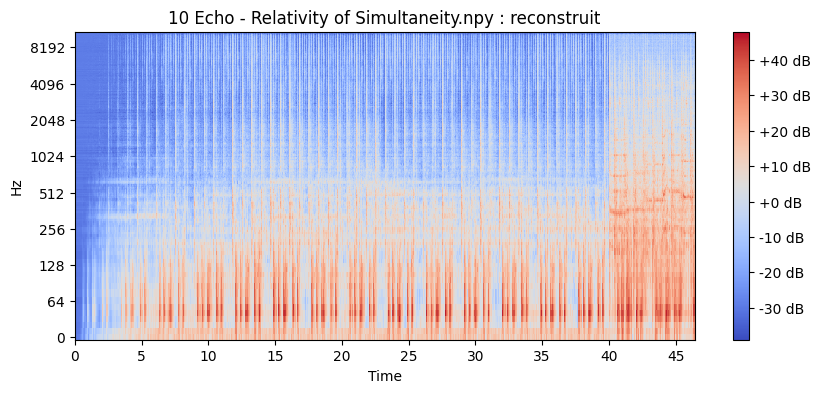

In [17]:
path1 = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\projet deep L3S2\\tout_spec"
path2 = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\projet deep L3S2\\spec"
path_piano = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\projet deep L3S2\\spec_piano"
path3 = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\projet deep L3S2\\test_rnn"

for f in os.listdir(path1):
    if f.endswith('.npy'):
        if f not in os.listdir(path2):
            file_path = os.path.join(path1, f)
            data = np.load(file_path)
            spec_tensor = torch.from_numpy(data).float()
            mini, maxi = spec_tensor.min(), spec_tensor.max()
            normalize_tensor = normalization(spec_tensor, mini, maxi)
            # Convertir en tenseur PyTorch et ajouter une dimension pour le canal
            normalize_tensor = normalize_tensor.unsqueeze(0)
            model.eval()
            with torch.no_grad():
                # Reconstruction
                original_input = normalize_tensor.permute(0, 2, 1).to(device)  # (1, 2000, 1025)
                reconstructed = model(original_input).permute(0, 2, 1)
            reconstructed = reconstructed.squeeze(0).cpu().detach().numpy()
            reconstructed2 = denormalization(reconstructed, mini.item(), maxi.item())
            # Enregistrer le fichier audio
            # Enregistrer le spectrogramme
            # Enregistrer l'image
            # Spectrogramme reconstruit
            plt.figure(figsize=(10, 4))
            librosa.display.specshow(reconstructed2, y_axis='log', x_axis='time')
            plt.colorbar(format='%+2.0f dB')
            plt.title(f"{f} : reconstruit")
            img_name = f.replace(".npy", "_reconstruit.png")
            img_path = os.path.join(path3, img_name)
            plt.savefig(img_path)
            plt.close()

            # Spectrogramme original
            plt.figure(figsize=(10, 4))
            librosa.display.specshow(spec_tensor.numpy(), y_axis='log', x_axis='time')
            plt.colorbar(format='%+2.0f dB')
            plt.title(f"{f} : original")
            img_name = f.replace(".npy", "_original.png")
            img_path = os.path.join(path3, img_name)
            plt.savefig(img_path)
            plt.close()

            
            
            audio_path = os.path.join(path3, f"audio_reconstruit.wav")
            spec_amp = librosa.db_to_amplitude(reconstructed2)
            signal = librosa.griffinlim(spec_amp, hop_length=512)

            sf.write(audio_path, signal, 22050)

            
            

            
            
            